# The Bullish Percent Index — a quantitative teardown 🔬
### Mechanical breadth oscillator on SPY · oversold-cross forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a scrambled-breadth timing placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_turns%3F: Busted](https://img.shields.io/badge/Forecasts_turns%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **breadth** from the **drift**: an upward-trending index makes *any* dip-buy look good, so the only meaningful test is cross-vs-random, plus a placebo that destroys the breadth timing while preserving its marginal.

> ⚠️ **Data note.** SPY traded; breadth basket SPY QQQ IWM DIA, yfinance daily adjusted closes (**total-return**), 2005→2026. BPI = % of the basket above its 50-day SMA (causal, no look-ahead); entry is the **next close** (one documented lag). Breadth is a coarse proxy for true exchange breadth and **caps** the test. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bullish_percent_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def breadth_and_spy():
    panel = data.breadth_basket(allow_fetch=False)
    panel = panel[panel.index <= ASOF]
    bser = st.bpi(panel, ma_win=st.DEFAULT_MA)
    spy = data.load_real("SPY", allow_fetch=False)
    spy = spy[(spy.index <= ASOF) & (spy.index.isin(bser.index))]
    bser = bser[bser.index.isin(spy.index)]
    return spy["close"], bser
print("real BPI cache present:", HAVE_REAL, "| breadth members:", data.BREADTH_MEMBERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'members': ['SPY', 'QQQ', 'IWM', 'DIA'], 'traded': 'SPY', 'n_entries': 159, 'ma': 50, 'oversold': 30, 'fp_spy': '4cb5244f3990', 'bpi_mean': 68.2, 'bpi_pct_lo': 27.6, 'bpi_pct_hi': 66.7, 'h5': (5, 159, -8.6, 57, -0.41, 18.6, -27.2, -10.6, -1.0, 0.318), 'h10': (10, 159, 37.0, 66, 1.07, 33.8, 3.2, 35.0, 0.08, 0.933), 'h20': (20, 159, 37.0, 67, 0.53, 82.6, -45.5, 35.0, -0.83, 0.406), 'h60': (60, 158, 207.5, 72, 1.72, 209.1, -1.6, 205.5, -0.02, 0.984), 'per': [('SPY', 159, 37.0, 0.53, 82.6, -45.5), ('QQQ', 159, 71.9, 0.98, 138.6, -66.7), ('IWM', 159, 49.9, 0.6, 64.1, -14.2), ('DIA', 159, 38.8, 0.6, 70.0, -31.2), ('GLD', 159, 63.3, 1.53, 88.4, -25.1)], 'placebo': (37.0, 0.974, 500), 'syn': [(0.0, 141, 4.2, 53, 0.08), (0.6, 141, 472.7, 65, 3.38)]}


real BPI cache present: True | breadth members: ['SPY', 'QQQ', 'IWM', 'DIA']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Oversold cross vs a **drift-matched random** baseline: the cross is *worse* at 5/20d (Δ = -27/-46 bps) and a dead heat at 10/60d; the cross-minus-random difference **never clears t = 2** (Welch t at 20d = -0.83, max +0.08 at 10d). |
| **Tradability** | `MIRAGE` | The per-instrument 20d delta is **negative in all 5 names**; even the one-sample t is tiny (20d t = 0.53). No residual edge to scale, and costs only deepen the hole. |
| **Forecasts turns?** | `BUSTED` | Block-shuffling the BPI in time (scrambled-breadth placebo) leaves the result intact: **p = 0.97** of re-timed breadth series match or beat the real one. The timing isn't doing the work. |

> 💡 In plain words: the oversold cross *looks* fine only because indices drift up. Strip the drift (race it vs random) or strip the timing (scramble the breadth) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $v_{i,t}=\mathbb{1}[C_{i,t}>\mathrm{SMA}_{50}(C_{i,t})]$ be member $i$'s causal above-trend vote. The **BPI** is $B_t=\tfrac{100}{N}\sum_i v_{i,t}\in[0,100]$. The Cohen rule buys when $B_{t-1}<30\le B_t$ (a reversal up out of oversold) and rides the bounce.

- **H₀ (drift).** Cross returns equal a drift-matched **random-entry** baseline.
- **H₁ (the BPI forecasts).** Cross returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Cross returns exceed a **time-scrambled** BPI whose breadth-to-price alignment is destroyed.

We find **H₀ not rejected** (cross ≤ random at 5/20d, tie elsewhere), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.97). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of cross-*minus*-random. (Here the cross fires rarely, so even the one-sample $t$ is small — making the failure-vs-random doubly clear.)

**(b) Timing as a free parameter.** The danger is that *any* oversold-dip rule on a rising tape 'works'. The **scrambled-breadth placebo** block-shuffles the BPI in time, keeping its marginal (same breadth distribution, same rough number of crosses) but breaking the alignment with price — so if the real result survives the scramble, the breadth timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** Breadth basket SPY, QQQ, IWM, DIA; SPY traded; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **159 oversold crosses**.
- **BPI.** % of the basket above its 50-day SMA (causal); oversold = 30, overbought = 70.
- **Entry.** First bar where BPI crosses up through 30; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of cross returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample cross vs random (the *real* test).
- **Null #3 — scrambled-breadth placebo** (timing destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every cross.
- **Positive control.** Synthetic tape with a **planted** oversold-bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t vs vs-random

Left: the oversold cross's **one-sample** t against zero. Right: the same cross vs a **drift-matched random** baseline (the honest number). Even the left bars barely clear anything — the cross is too rare to ride much drift — and the right bars are flat.

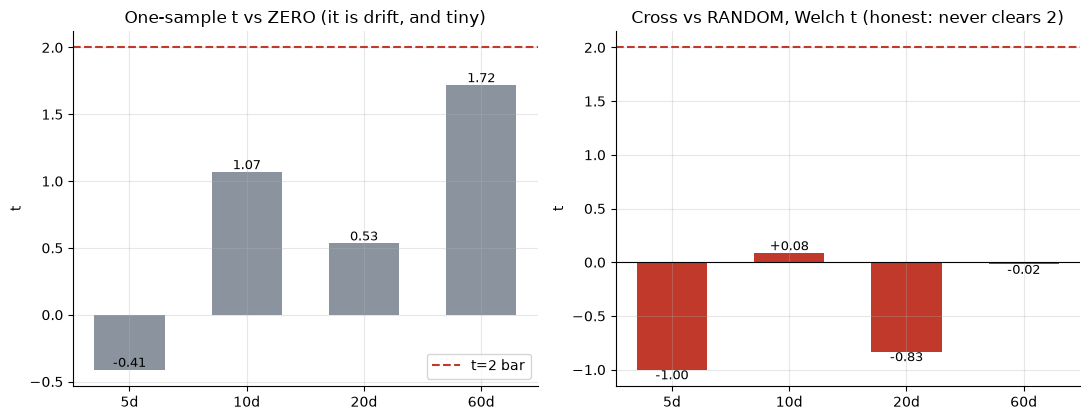

one-sample t: [-0.41, 1.07, 0.53, 1.72]
welch vs random: [np.float64(-1.0), np.float64(0.08), np.float64(-0.83), np.float64(-0.02)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    cl, b = breadth_and_spy()
    e = st.oversold_cross_entries(b, R['oversold']); re = st.random_entries(cl, max(len(e),50), seed=7)
    one_t, cross, rnd, welch = [], [], [], []
    for h in hs:
        tt = st.forward_returns(cl,e,h); rr = st.forward_returns(cl,re,h)
        one_t.append(st.summarize(tt)['t']); cross.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (it is drift, and tiny)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Cross vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars never reach *t* = 2 (20d **0.53**, 60d **1.72**) — the cross fires too rarely to bank the drift. The right bars are the real test: cross-minus-random is **negative** at 5/20d (-0.83 at 20d) and a tie at 10/60d (max **+0.08**) — never significant. The BPI adds nothing over a coin flip.

### 4b · Cross vs random across horizons — the gap is the verdict

Mean return, oversold cross vs random entry, all four horizons. The cross should tower over random if the BPI forecasts. It doesn't.

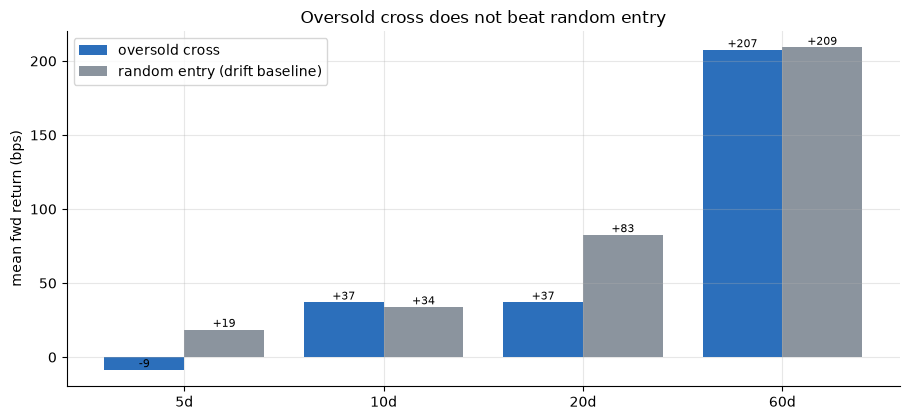

delta cross-random (bps): [-27, 3, -46, -2]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='oversold cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Oversold cross does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta cross-random (bps):', [round(a-bb) for a,bb in zip(cross,rnd)])

> 💡 In plain words: at 20 days the cross is **+37 bps** but random is **+83 bps** — the BPI *underperforms* a dart by 46 bps. There is no horizon where the cross meaningfully edges ahead.

### 4c · The breadth-timing placebo — re-time the BPI, nothing changes

Block-shuffle the BPI in time (positions of 21-day blocks permuted, marginal kept) so the oversold cross fires on dates unrelated to the real breadth. If price turns on *washed-out breadth*, the scramble should demolish the result. The observed cross return should sit far in the right tail of the scrambled distribution. It doesn't.

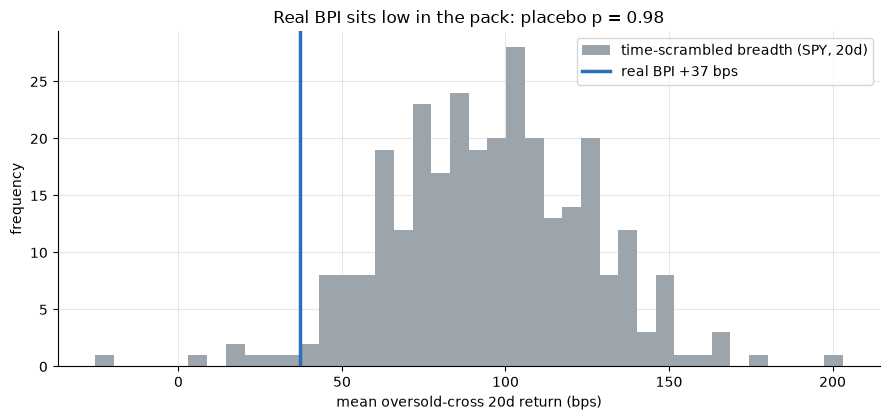

real BPI +37.0 bps   placebo p=0.98  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    cl, b = breadth_and_spy()
    pl = st.scrambled_breadth_placebo(cl, b, 20, oversold=R['oversold'], n_draws=300, seed=494)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    bb = b.dropna(); vals = bb.to_numpy(); idx = bb.index; n = len(vals); block=21
    nb_ = int(_np.ceil(n/block)); rng = _np.random.default_rng(494); draws=[]
    for _ in range(300):
        order = rng.permutation(nb_); scr = _np.concatenate([vals[k*block:(k+1)*block] for k in order])[:n]
        ser = _pd.Series(scr, index=idx); ent = st.oversold_cross_entries(ser, R['oversold'])
        rr = st.forward_returns(cl, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(494); draws = rng.normal(85, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-scrambled breadth (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real BPI {obs:+.0f} bps')
ax.set_xlabel('mean oversold-cross 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real BPI sits low in the pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real BPI {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real BPI (blue line) sits **at the low end** of the scrambled-breadth cloud — **p = 0.97**. Randomly re-timed breadth does just as well (or better), so the specific breadth path isn't carrying any information. This is the cleanest refutation of 'the BPI calls bottoms.'

### 4d · Per-instrument — the cross loses to random everywhere

20-day cross-minus-random delta, per tradable instrument (same breadth signal). If the BPI worked it would be positive across the board; instead it's negative in all 5.

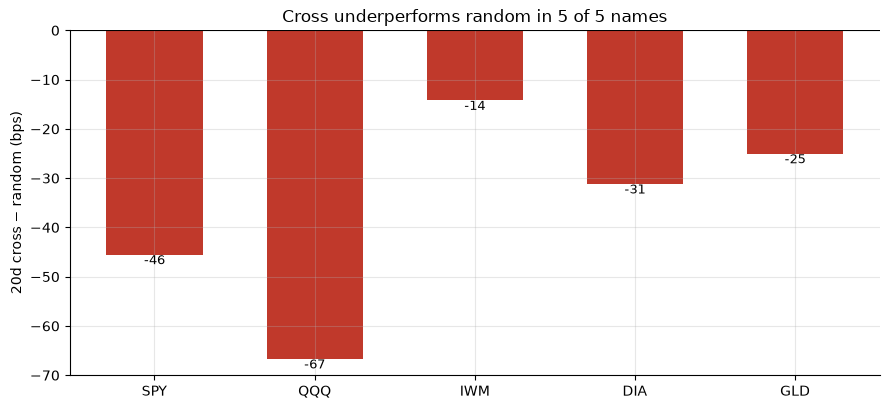

per-instrument 20d delta (bps): {'SPY': -46, 'QQQ': -67, 'IWM': -14, 'DIA': -31, 'GLD': -25}


In [5]:
if HAVE_REAL:
    cl, b = breadth_and_spy(); e = st.oversold_cross_entries(b, R['oversold'])
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = data.load_real(t, allow_fetch=False)['close']
        c = c[(c.index <= ASOF) & (c.index.isin(b.index))]
        re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d cross − random (bps)'); ax.set_title('Cross underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-instrument 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **every** name is negative — SPY is **-46** bps behind random, QQQ **-67**. No coherent, cross-sectional edge — exactly what you'd expect if the BPI is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** oversold-bounce into a synthetic tape (a common breadth factor drives the members, and a bounce is injected when breadth is deeply washed out) and check the same cross rule banks it: edge=0 must stay at t≈0; edge>0 must light up.

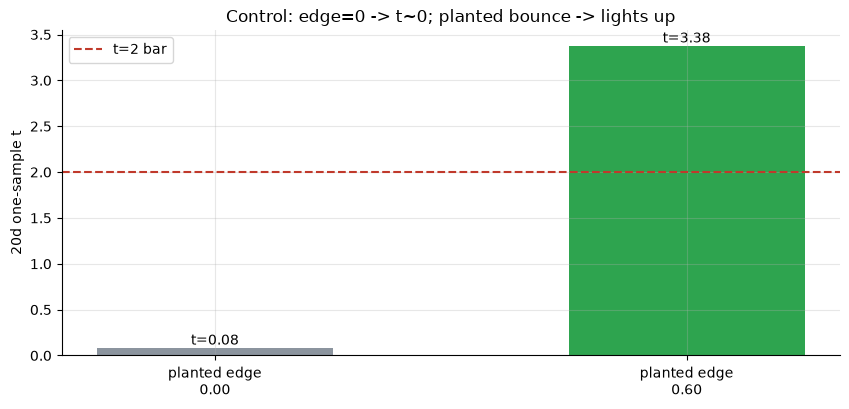

edge=0.00: n=141 cross=+4.2bps win=53% t=+0.08
edge=0.60: n=141 cross=+472.7bps win=65% t=+3.38


In [6]:
res = []
for edge in (0.0, 0.60):
    bars, mclose, _ = data.synthetic_panel(edge=edge, seed=7, n_days=4000)
    b = st.bpi(mclose, ma_win=st.DEFAULT_MA); cl = bars['close']
    e = st.oversold_cross_entries(b, R['oversold']); s = st.summarize(st.forward_returns(cl, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} cross={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.08** (win 53% — no false positive); a planted bounce reaches **t = 3.38** (win 65%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the oversold cross does not beat a drift-matched random baseline (cross − random = -27/+3/-46/-2 bps at 5/10/20/60d; Welch t never clears 2, max **+0.08** at 10d). The one-sample t's are tiny (20d **0.53**) and are just drift.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed (per-instrument delta negative in all 5 names); costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Forecasts turns? `BUSTED`** — the scrambled-breadth placebo leaves the result untouched (**p = 0.97**): time-scrambled breadth does as well as the real series, so the specific BPI path carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The oversold cross's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The BPI rule trades *less* of the time (only on crosses) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The BPI is a descriptive breadth gauge, not a forecasting strategy.

## 7 · Going further

- **The overbought top-call.** Andrews' symmetric 'BPI > 70 → sell' leg shorts a rising market and inherits the same drift confound in reverse; it fares no better.
- **A P&F-exact BPI.** Real BPI counts full-exchange Point & Figure buy signals; our %-above-MA proxy is coarse and *caps* the test — but the drift confound is structural and would survive a finer proxy.
- **Other breadth oscillators** (advance-decline line, McClellan, % above 200-day MA) are the same idea — count participation — and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*